## Importações e Configuração

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


## Carregamento dos Dados de Latência

Vamos carregar os logs de requisições que contêm informações de latência.

In [2]:
# Carregar logs de requisições
with open('flask-app/requests.log', 'r') as f:
    logs = [json.loads(line) for line in f]

# Criar DataFrame com informações relevantes
latency_data = pd.DataFrame([
    {
        'timestamp': log['timestamp'],
        'latency_ms': log['latency_ms'],
        'status_code': log['status_code'],
        'request_id': log['request_id']
    }
    for log in logs
])

# Converter timestamp para datetime
latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])
latency_data['request_num'] = range(1, len(latency_data) + 1)

print(f"📊 Total de requisições: {len(latency_data)}")
print(f"\n📅 Período: {latency_data['timestamp'].min()} até {latency_data['timestamp'].max()}")
print(f"\n✓ Primeiras requisições:")
latency_data.head()

📊 Total de requisições: 100

📅 Período: 2025-11-20 20:50:04.701834+00:00 até 2025-11-20 20:50:11.475827+00:00

✓ Primeiras requisições:


,timestamp,latency_ms,status_code,request_id,request_num
0,2025-11-20 20:50:04.701834+00:00,9.423,200,3d6b837f-f629-4875-b88a-fa81dc230a54,1
1,2025-11-20 20:50:04.766333+00:00,7.463,200,afde3c78-4b5e-4c9d-8191-c11af3c57340,2
2,2025-11-20 20:50:04.827215+00:00,8.833,200,7a838c75-c98f-498a-a5ed-69839a57103b,3
3,2025-11-20 20:50:04.893502+00:00,9.643,200,3a1bd24d-96c4-4d2b-b38a-6135b830dece,4
4,2025-11-20 20:50:04.960564+00:00,10.091,200,d226250d-7899-452c-bcf0-d575f4d6747f,5


## Estatísticas Descritivas de Latência

Vamos calcular as principais métricas estatísticas para entender o comportamento da latência.

In [3]:
# Calcular estatísticas descritivas
stats = {
    'Métrica': [
        'Média (ms)',
        'Mediana (ms)',
        'Desvio Padrão (ms)',
        'Mínimo (ms)',
        'Máximo (ms)',
        'P50 - Mediana (ms)',
        'P90 (ms)',
        'P95 (ms)',
        'P99 (ms)'
    ],
    'Valor': [
        latency_data['latency_ms'].mean(),
        latency_data['latency_ms'].median(),
        latency_data['latency_ms'].std(),
        latency_data['latency_ms'].min(),
        latency_data['latency_ms'].max(),
        latency_data['latency_ms'].quantile(0.50),
        latency_data['latency_ms'].quantile(0.90),
        latency_data['latency_ms'].quantile(0.95),
        latency_data['latency_ms'].quantile(0.99)
    ]
}

stats_df = pd.DataFrame(stats)

print("=" * 80)
print("ESTATÍSTICAS DE LATÊNCIA - PRODUÇÃO")
print("=" * 80)
display(stats_df.round(2))

print("\n💡 Interpretação dos Percentis:")
print(f"   • P50 (mediana): 50% das requisições têm latência ≤ {stats_df[stats_df['Métrica']=='P50 - Mediana (ms)']['Valor'].values[0]:.2f} ms")
print(f"   • P90: 90% das requisições têm latência ≤ {stats_df[stats_df['Métrica']=='P90 (ms)']['Valor'].values[0]:.2f} ms")
print(f"   • P95: 95% das requisições têm latência ≤ {stats_df[stats_df['Métrica']=='P95 (ms)']['Valor'].values[0]:.2f} ms")
print(f"   • P99: 99% das requisições têm latência ≤ {stats_df[stats_df['Métrica']=='P99 (ms)']['Valor'].values[0]:.2f} ms")

ESTATÍSTICAS DE LATÊNCIA - PRODUÇÃO


,Métrica,Valor
0,Média (ms),11.53
1,Mediana (ms),11.52
2,Desvio Padrão (ms),2.69
3,Mínimo (ms),6.11
4,Máximo (ms),29.28
5,P50 - Mediana (ms),11.52
6,P90 (ms),14.04
7,P95 (ms),14.40
8,P99 (ms),14.91



💡 Interpretação dos Percentis:
   • P50 (mediana): 50% das requisições têm latência ≤ 11.52 ms
   • P90: 90% das requisições têm latência ≤ 14.04 ms
   • P95: 95% das requisições têm latência ≤ 14.40 ms
   • P99: 99% das requisições têm latência ≤ 14.91 ms


## Visualização da Distribuição de Latência

Vamos visualizar como a latência está distribuída usando histograma e boxplot.

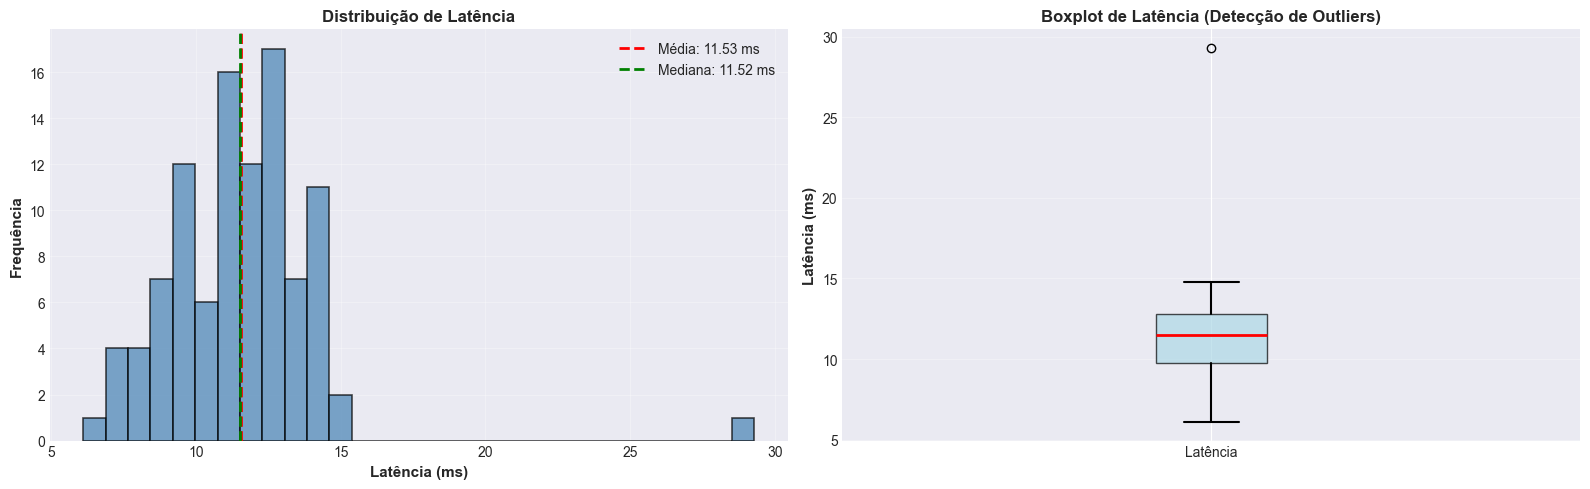


Outliers detectados: 1 requisições com latência > 17.44 ms
   Latências dos outliers: [29.283]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma da distribuição de latência
ax1 = axes[0]
ax1.hist(latency_data['latency_ms'], bins=30, alpha=0.7, color='steelblue', 
         edgecolor='black', linewidth=1.2)
ax1.axvline(latency_data['latency_ms'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Média: {latency_data["latency_ms"].mean():.2f} ms')
ax1.axvline(latency_data['latency_ms'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Mediana: {latency_data["latency_ms"].median():.2f} ms')
ax1.set_xlabel('Latência (ms)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequência', fontsize=11, fontweight='bold')
ax1.set_title('Distribuição de Latência', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Boxplot para identificar outliers
ax2 = axes[1]
box = ax2.boxplot(latency_data['latency_ms'], vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))
ax2.set_ylabel('Latência (ms)', fontsize=11, fontweight='bold')
ax2.set_title('Boxplot de Latência (Detecção de Outliers)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['Latência'])

plt.tight_layout()
plt.show()

# Identificar outliers
Q1 = latency_data['latency_ms'].quantile(0.25)
Q3 = latency_data['latency_ms'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = latency_data[latency_data['latency_ms'] > outlier_threshold]

print(f"\nOutliers detectados: {len(outliers)} requisições com latência > {outlier_threshold:.2f} ms")
if len(outliers) > 0:
    print(f"   Latências dos outliers: {outliers['latency_ms'].tolist()}")

## Latência ao Longo do Tempo

Visualizar como a latência evolui ao longo das requisições para identificar tendências ou degradação de performance.

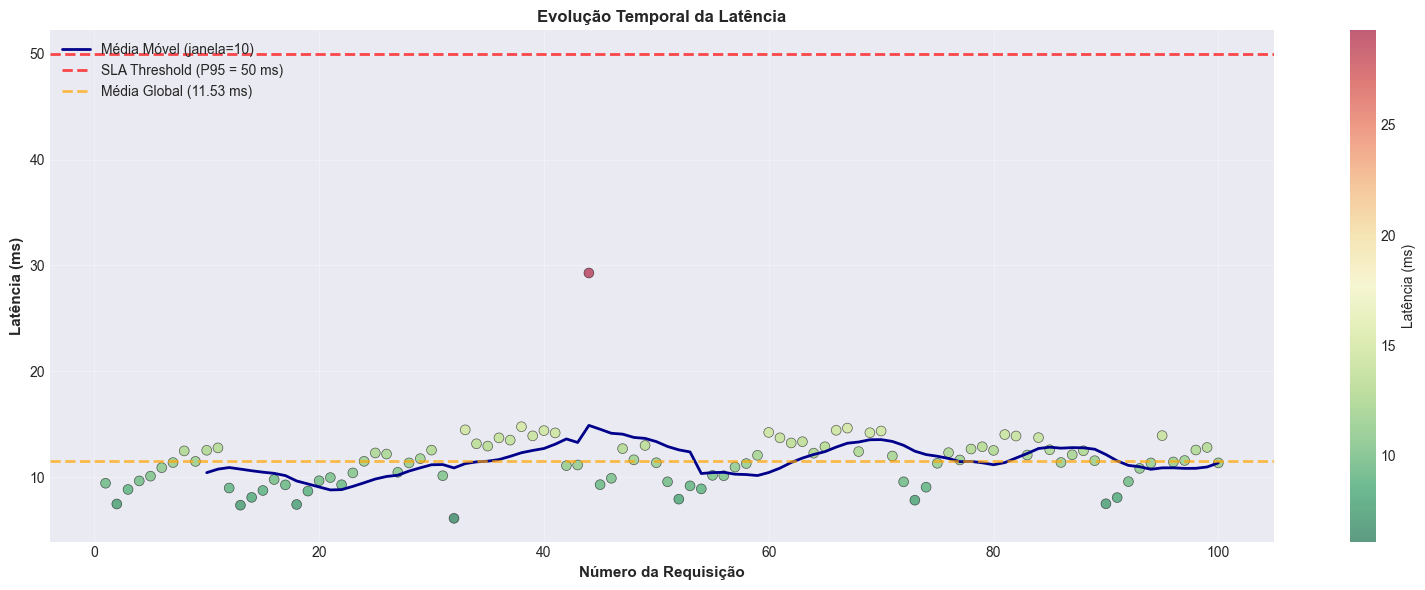


 Análise Temporal:
   • Tendência: Verifique se a linha azul (média móvel) está aumentando ao longo do tempo
   • SLA: 0 requisições excederam o threshold de 50 ms


In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

# Scatter plot com linha de tendência
scatter = ax.scatter(latency_data['request_num'], latency_data['latency_ms'],
                     c=latency_data['latency_ms'], cmap='RdYlGn_r',
                     alpha=0.6, s=50, edgecolor='black', linewidth=0.5)

# Adicionar média móvel (rolling average) para suavizar tendências
window_size = 10
latency_data['rolling_mean'] = latency_data['latency_ms'].rolling(window=window_size).mean()
ax.plot(latency_data['request_num'], latency_data['rolling_mean'],
        color='darkblue', linewidth=2, label=f'Média Móvel (janela={window_size})')

# Threshold lines (exemplo: SLA de 50ms para P95)
p95_threshold = 50  # ms
ax.axhline(y=p95_threshold, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'SLA Threshold (P95 = {p95_threshold} ms)')

# Adicionar média geral
ax.axhline(y=latency_data['latency_ms'].mean(), color='orange', linestyle='--',
           linewidth=2, alpha=0.7, label=f'Média Global ({latency_data["latency_ms"].mean():.2f} ms)')

ax.set_xlabel('Número da Requisição', fontsize=11, fontweight='bold')
ax.set_ylabel('Latência (ms)', fontsize=11, fontweight='bold')
ax.set_title('Evolução Temporal da Latência', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Colorbar para indicar escala de latência
cbar = plt.colorbar(scatter, ax=ax, label='Latência (ms)')

plt.tight_layout()
plt.show()

print("\n Análise Temporal:")
print(f"   • Tendência: Verifique se a linha azul (média móvel) está aumentando ao longo do tempo")
print(f"   • SLA: {len(latency_data[latency_data['latency_ms'] > p95_threshold])} requisições excederam o threshold de {p95_threshold} ms")

## Análise de Percentis ao Longo do Tempo

Monitorar como os percentis (P50, P90, P95, P99) evoluem em janelas deslizantes.

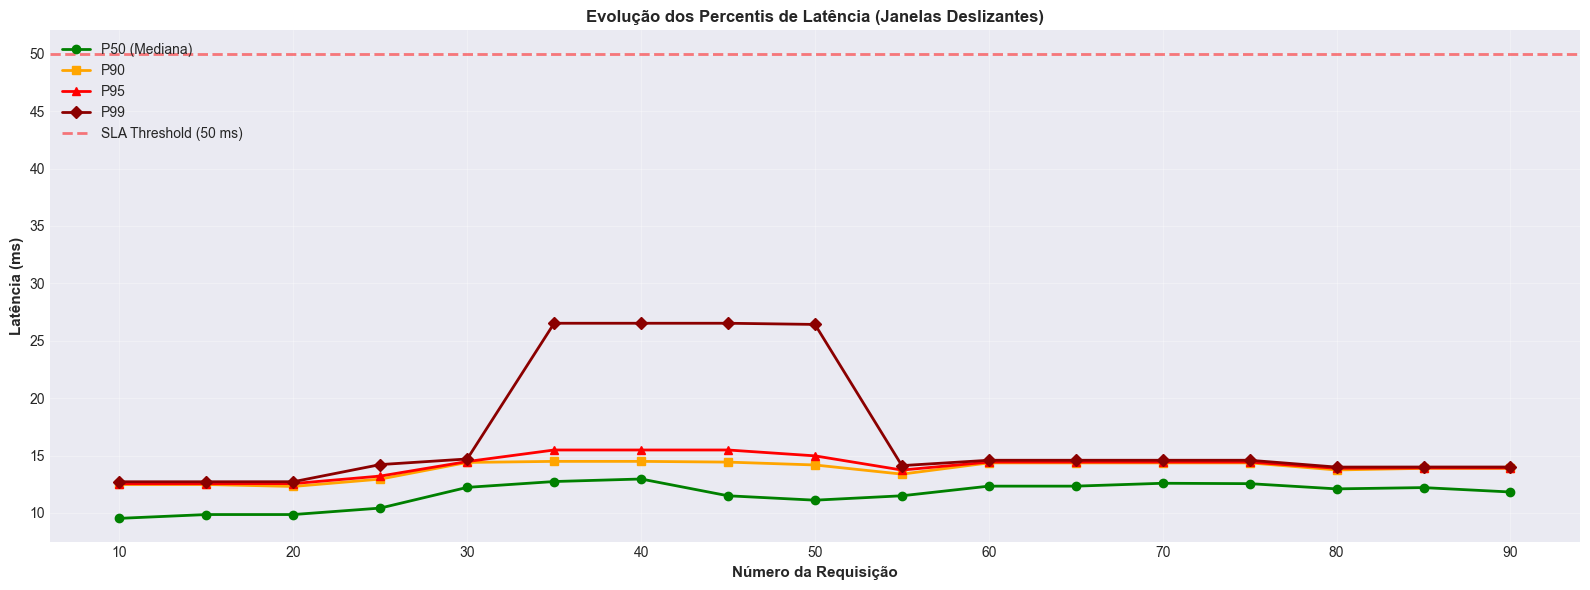


 Interpretação:
   • Se P95 ou P99 aumentam consistentemente, pode indicar degradação de performance
   • Se P99 >> P95, há requisições com latência muito alta (tail latency)


In [6]:
# Calcular percentis em janelas deslizantes
window_size = 20
step = 5

rolling_percentiles = []

for i in range(0, len(latency_data) - window_size + 1, step):
    window = latency_data.iloc[i:i+window_size]
    rolling_percentiles.append({
        'window_center': i + window_size // 2,
        'p50': window['latency_ms'].quantile(0.50),
        'p90': window['latency_ms'].quantile(0.90),
        'p95': window['latency_ms'].quantile(0.95),
        'p99': window['latency_ms'].quantile(0.99)
    })

rolling_df = pd.DataFrame(rolling_percentiles)

# Visualizar
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(rolling_df['window_center'], rolling_df['p50'], marker='o', linewidth=2,
        markersize=6, label='P50 (Mediana)', color='green')
ax.plot(rolling_df['window_center'], rolling_df['p90'], marker='s', linewidth=2,
        markersize=6, label='P90', color='orange')
ax.plot(rolling_df['window_center'], rolling_df['p95'], marker='^', linewidth=2,
        markersize=6, label='P95', color='red')
ax.plot(rolling_df['window_center'], rolling_df['p99'], marker='D', linewidth=2,
        markersize=6, label='P99', color='darkred')

# Threshold SLA
ax.axhline(y=p95_threshold, color='red', linestyle='--', linewidth=2, alpha=0.5,
           label=f'SLA Threshold ({p95_threshold} ms)')

ax.set_xlabel('Número da Requisição', fontsize=11, fontweight='bold')
ax.set_ylabel('Latência (ms)', fontsize=11, fontweight='bold')
ax.set_title('Evolução dos Percentis de Latência (Janelas Deslizantes)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interpretação:")
print("   • Se P95 ou P99 aumentam consistentemente, pode indicar degradação de performance")
print("   • Se P99 >> P95, há requisições com latência muito alta (tail latency)")

## Sistema de Alertas Baseado em Thresholds

Definir regras de alerta para monitoramento em produção.

In [7]:
# Definir thresholds de SLA
thresholds = {
    'P50': 20,   # ms - 50% das requisições devem responder em até 20ms
    'P90': 35,   # ms - 90% das requisições devem responder em até 35ms
    'P95': 50,   # ms - 95% das requisições devem responder em até 50ms
    'P99': 100   # ms - 99% das requisições devem responder em até 100ms
}

# Calcular percentis atuais
current_percentiles = {
    'P50': latency_data['latency_ms'].quantile(0.50),
    'P90': latency_data['latency_ms'].quantile(0.90),
    'P95': latency_data['latency_ms'].quantile(0.95),
    'P99': latency_data['latency_ms'].quantile(0.99)
}

# Avaliar SLA
sla_report = []
for percentil, threshold in thresholds.items():
    current_value = current_percentiles[percentil]
    status = '✓ OK' if current_value <= threshold else '🔴 VIOLAÇÃO'
    difference = current_value - threshold
    
    sla_report.append({
        'Percentil': percentil,
        'Threshold (ms)': threshold,
        'Valor Atual (ms)': current_value,
        'Diferença (ms)': difference,
        'Status': status
    })

sla_df = pd.DataFrame(sla_report)

print("=" * 100)
print("RELATÓRIO DE SLA - LATÊNCIA")
print("=" * 100)
display(sla_df.round(2))

# Decisão operacional
violations = sla_df[sla_df['Status'] == '🔴 VIOLAÇÃO']

print("\n" + "=" * 100)
print("DECISÃO OPERACIONAL")
print("=" * 100)

if len(violations) > 0:
    print(f"\n🔴 ALERTA: {len(violations)} violação(ões) de SLA detectada(s)!")
    for _, row in violations.iterrows():
        print(f"   • {row['Percentil']}: {row['Valor Atual (ms)']:.2f} ms (threshold: {row['Threshold (ms)']} ms)")
    
    print("\n AÇÕES RECOMENDADAS:")
    print("   1. Investigar causa raiz (logs de infraestrutura, métricas de CPU/memória)")
    print("   2. Verificar se há sobrecarga no servidor")
    print("   3. Analisar se o modelo está consumindo mais recursos")
    print("   4. Considerar otimizações (caching, batching, quantização do modelo)")
    print("   5. Escalar horizontalmente (adicionar mais instâncias)")
else:
    print("\n✓ Status: SLA de latência está sendo cumprido")
    print("   Continue monitorando regularmente.")

print("\n" + "=" * 100)

RELATÓRIO DE SLA - LATÊNCIA


,Percentil,Threshold (ms),Valor Atual (ms),Diferença (ms),Status
0,P50,20,11.52,-8.48,✓ OK
1,P90,35,14.04,-20.96,✓ OK
2,P95,50,14.40,-35.60,✓ OK
3,P99,100,14.91,-85.09,✓ OK



DECISÃO OPERACIONAL

✓ Status: SLA de latência está sendo cumprido
   Continue monitorando regularmente.



## Resumo e Boas Práticas

### O que aprendemos:

1. **Métricas de Latência**:
   - **Média**: fácil de calcular, mas sensível a outliers
   - **Mediana (P50)**: mais robusta que a média
   - **P95/P99**: capturam "tail latency" (piores casos)

2. **Análise Temporal**:
   - Médias móveis suavizam ruído e revelam tendências
   - Percentis em janelas deslizantes detectam degradação gradual

3. **Thresholds de SLA**:
   - Defina baseado em requisitos de negócio
   - Monitore principalmente P95 e P99 (experiência do usuário)

### Boas Práticas:

1. **Monitoramento Contínuo**:
   - Colete métricas de latência em todas as requisições
   - Agregue por minuto/hora para análise de tendências

2. **Alertas Inteligentes**:
   - Configure alertas baseados em percentis (P95, P99)
   - Evite alertas apenas em média (pode esconder problemas)

3. **Investigação de Causa Raiz**:
   - Correlacione latência com outras métricas (CPU, memória, rede)
   - Mantenha logs detalhados para debugging

4. **Otimizações Comuns**:
   - **Caching**: armazenar predições de inputs frequentes
   - **Batching**: processar múltiplas requisições juntas
   - **Quantização**: reduzir precisão do modelo (FP32 → FP16)
   - **Model distillation**: criar modelo menor e mais rápido
   - **Hardware**: usar GPUs para inferência pesada

5. **Ferramentas Recomendadas**:
   - **Prometheus + Grafana**: coleta e visualização de métricas
   - **ELK Stack**: logs centralizados e análise
   - **DataDog / New Relic**: APM (Application Performance Monitoring)
   - **MLflow**: tracking de performance de modelos